# 02 · Cross-market OLS, cointegration and the choice of the rolling window

Notebook 01 showed that the basket sum mean-reverts while its legs wander. Here we:

1. test the **within-basket** structure formally: Johansen rank and the cointegrating vector (theory: rank 1, vector ∝ ι = (1,…,1));
2. test a **cross-market identity** between two different events: `P(Democrats win the House)` must equal
   `P(Democrats Sweep) + P(R Senate, D House)` from the Balance-of-Power event;
3. choose the engine's **rolling window N and z thresholds** by walk-forward validation (train → validate → untouched test), so the
   backtest in notebook 03 is not fitted to its own evaluation data.

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Markdown, display
from src import plotting as P, stats_tools as st, research as R, RESULTS_ROOT
from src.config import load_markets, get_basket, basket_fee_per_unit
from src.arb_engine import ZConfig, zscore_batch
from src.pipeline import fast_grid
pd.set_option("display.float_format", "{:.4f}".format)
cfg = load_markets()

In [2]:
fed, info_fed = R.price_panel("fed-oct-2026", cfg)
bop, info_bop = R.price_panel("balance-of-power-2026", cfg)
house, info_house = R.price_panel("house-2026", cfg)
senate, info_senate = R.price_panel("senate-2026", cfg)
for i in (info_fed, info_bop, info_house, info_senate):
    display(Markdown(i.banner_markdown()))
DK = info_fed.label

**DATA: REAL Polymarket price history** (`/prices-history`). Prices are real but not executable; wherever execution is simulated, bid/ask/depth are **MODELLED** around them.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `fed-oct-2026` (Fed Decision in October?) | 2026-09-02T03:01:00 | 2026-10-02T02:59:00 | 720.0 | 43,189 | 1 |

> Execution books are MODELLED: per-leg spread 50-bps-decrease=1 tick(s), 25-bps-decrease=1 tick(s), no-change=1 tick(s), 25-bps-increase=1 tick(s), 50-bps-increase=1 tick(s) (default 1 tick).

**DATA: REAL Polymarket price history** (`/prices-history`). Prices are real but not executable; wherever execution is simulated, bid/ask/depth are **MODELLED** around them.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `balance-of-power-2026` (Balance of Power: 2026 Midterms) | 2026-09-02T03:01:00 | 2026-10-02T02:59:00 | 720.0 | 43,188 | 1 |

> Execution books are MODELLED: per-leg spread democrats-sweep=1 tick(s), d-senate-r-house=1 tick(s), r-senate-d-house=1 tick(s), republicans-sweep=1 tick(s), other=1 tick(s) (default 1 tick).

**DATA: REAL Polymarket price history** (`/prices-history`). Prices are real but not executable; wherever execution is simulated, bid/ask/depth are **MODELLED** around them.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `house-2026` (Which party will win the House in 2026?) | 2026-09-02T03:01:00 | 2026-10-02T02:59:00 | 720.0 | 43,190 | 1 |

> Execution books are MODELLED: per-leg spread democratic-party=1 tick(s), republican-party=1 tick(s) (default 1 tick).

**DATA: REAL Polymarket price history** (`/prices-history`). Prices are real but not executable; wherever execution is simulated, bid/ask/depth are **MODELLED** around them.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `senate-2026` (Which party will win the Senate in 2026?) | 2026-09-02T03:02:00 | 2026-10-02T03:00:00 | 720.0 | 43,190 | 1 |

> Execution books are MODELLED: per-leg spread democratic-party=1 tick(s), republican-party=1 tick(s) (default 1 tick).

## 1. Within one basket: Johansen and the identity regression

With $n$ legs that must sum to a constant, the legs share $n-1$ stochastic trends, so the Johansen rank should be **1** and the cointegrating
vector should point along ι. Pinned long shots are stationary on their own (each would add a spurious rank), so the tail is aggregated into a
single `rest` leg first. The identity regression $p_{\text{no change}} = \alpha + \beta \sum_{j\neq i} p_j$ should give $\beta\approx-1$ and
$\alpha\approx 1+$ overround: a data check more than an estimate.

In [3]:
agg = st.aggregate_tail_legs(fed, max_legs=3)
jo = st.johansen(agg)
display(pd.DataFrame({"trace stat": jo["lr1"], "trace 95% cv": np.asarray(jo["cvt"])[:, 1],
                      "max-eig stat": jo["lr2"], "max-eig 95% cv": np.asarray(jo["cvm"])[:, 1]},
                     index=[f"r <= {i}" for i in range(len(jo["lr1"]))]))
ir = st.identity_regression(fed["no-change"], fed.drop(columns="no-change").sum(axis=1))
display(Markdown(f"Johansen rank (trace / max-eig): **{jo['rank_trace']} / {jo['rank_maxeig']}**, angle between the leading "
                 f"cointegrating vector and ι: **{jo['angle_to_iota_deg']:.1f}°**.  \n"
                 f"Identity regression: β = **{ir['beta']:.3f}** (HAC se {ir['beta_se']:.3f}), α = **{ir['alpha']:.4f}**, R² = {ir['r2']:.4f}."))

,trace stat,trace 95% cv,max-eig stat,max-eig 95% cv
r <= 0,79.8588,29.7961,71.1230,21.1314
r <= 1,8.7359,15.4943,7.9818,14.2639
r <= 2,0.7540,3.8415,0.7540,3.8415


Johansen rank (trace / max-eig): **1 / 1**, angle between the leading cointegrating vector and ι: **5.8°**.  
Identity regression: β = **-1.039** (HAC se 0.009), α = **1.0288**, R² = 0.9948.

## 2. Across events: the House marginal vs the Balance-of-Power joint

`Which party will win the House?` and `Balance of Power: 2026 Midterms` are different Polymarket events with their own order books, so nothing
forces them to agree except arbitrageurs. If both resolve on the same definition of control:

$$P(\text{D House}) = P(\text{Democrats Sweep}) + P(\text{R Senate, D House}).$$

**First, the resolution rules** (they must match before a residual can be called mispricing):

In [4]:
b_h, b_s, b_b = (get_basket(x, cfg) for x in ("house-2026", "senate-2026", "balance-of-power-2026"))
for b, leg in ((b_h, "democratic-party"), (b_b, "democrats-sweep")):
    print(f"--- {b.title} / {b.leg_by_id(leg).label}\n{b.leg_by_id(leg).rules[:600]}\n")
display(Markdown("Note: Balance of Power also lists an `Other` outcome (e.g. independents controlling a chamber) and House/Senate are "
                 "*augmented* events with unnamed placeholders, so the identity can hold only up to those small probabilities."))

--- Which party will win the House in 2026? / Democratic Party
This market will resolve according to the party that wins control of the United States House of Representatives in the 2026 United States midterm election.

A party wins control of the United States House of Representatives if it wins a majority of the chamber’s voting seats. If no party wins a majority of voting seats, the chamber will be deemed controlled by the party with which the first elected Speaker of the House of the Congress that convenes after the 2026 midterm election is affiliated.

The following rules govern the counting of seats for determining which party wins control of the ch

--- Balance of Power: 2026 Midterms / Democrats Sweep
This market will resolve according to the party that wins control of the United States Senate and the party that wins control of the United States House of Representatives in the 2026 United States midterm election.

A party wins control of the United States Senate if it wins a ma

Note: Balance of Power also lists an `Other` outcome (e.g. independents controlling a chamber) and House/Senate are *augmented* events with unnamed placeholders, so the identity can hold only up to those small probabilities.

In [5]:
df = pd.concat({"bop": bop, "house": house, "senate": senate}, axis=1).dropna()
pairs = {
    "House D  vs  Dem Sweep + (R Sen, D House)": (df[("house", "democratic-party")], df[("bop", "democrats-sweep")] + df[("bop", "r-senate-d-house")]),
    "Senate D vs  Dem Sweep + (D Sen, R House)": (df[("senate", "democratic-party")], df[("bop", "democrats-sweep")] + df[("bop", "d-senate-r-house")]),
}
rows = []
for name, (y, x) in pairs.items():
    r = st.identity_residual_stats(y - x, 60.0)
    eg = st.engle_granger(y, x)
    rows.append({"pairing": name, "mean residual": r["mean"], "HAC t": r["t"] if "t" in r else r["hac_t"], "p": r["pvalue"],
                 "half-life (h)": r["half_life_s"] / 3600, "EG p (y~x)": eg["y_on_x"]["pvalue"], "EG p (x~y)": eg["x_on_y"]["pvalue"]})
pair_tab = pd.DataFrame(rows).set_index("pairing")
pair_tab["EG p (Holm, 4 tests)"] = st.holm(np.r_[pair_tab["EG p (y~x)"], pair_tab["EG p (x~y)"]])[: len(pair_tab)]
display(pair_tab)

,mean residual,HAC t,p,half-life (h),EG p (y~x),EG p (x~y),"EG p (Holm, 4 tests)"
pairing,,,,,,,
"House D vs Dem Sweep + (R Sen, D House)",0.0098,4.8704,0.0000,13.6183,0.0433,0.0375,0.0749
"Senate D vs Dem Sweep + (D Sen, R House)",-0.0024,-1.6436,0.1003,11.9172,0.0005,0.0007,0.0022


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


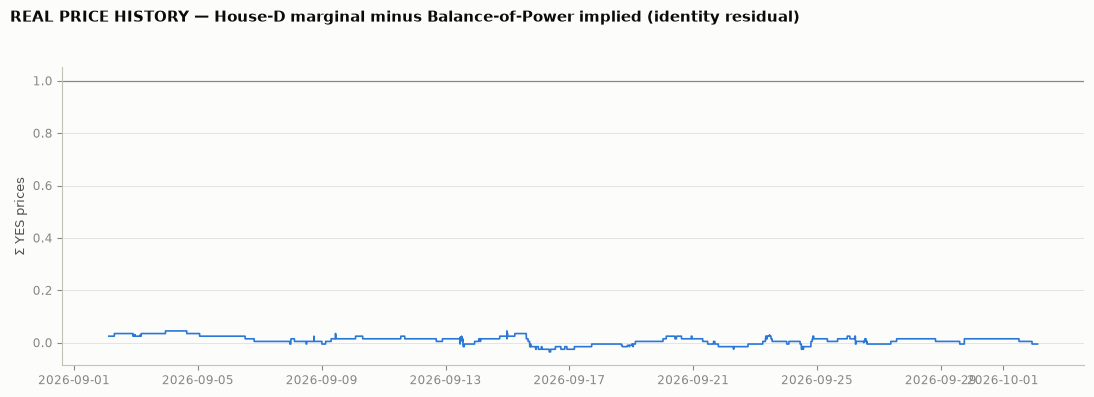

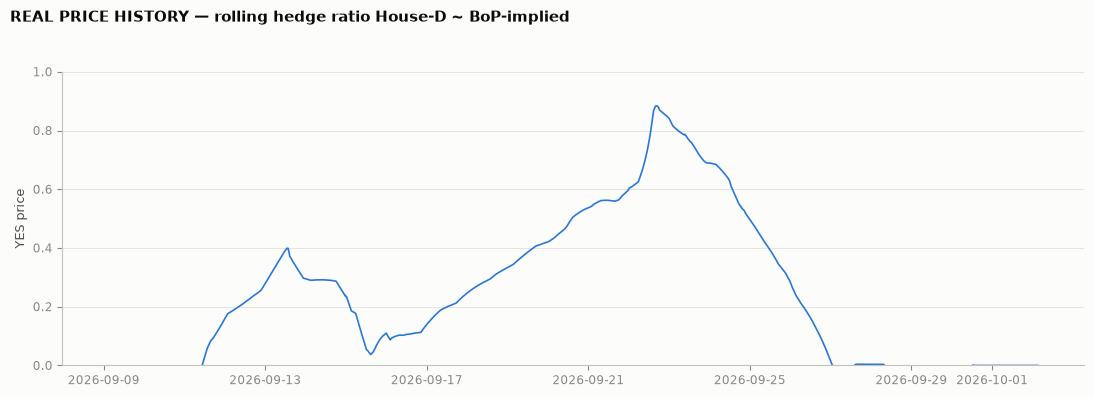

PosixPath('/home/user/bayes_project/results/figures/02_rolling_beta.png')

In [6]:
y, x = pairs["House D  vs  Dem Sweep + (R Sen, D House)"]
roll = st.rolling_ols_spread(y, x, window=7 * 1440)   # one-week window, parameters lagged by one step
show = pd.DataFrame({"s_mid": y - x}).assign(s_bid=np.nan, s_ask=np.nan)
P.show(P.plot_sum_band(pd.DataFrame({"s_mid": (y - x)}), data_kind=DK,
                       title="House-D marginal minus Balance-of-Power implied (identity residual)"), "02_house_identity_residual")
P.show(P.plot_legs(roll[["beta"]].dropna().rename(columns={"beta": "rolling β (1-week, lagged)"}), data_kind=DK,
                   title="rolling hedge ratio House-D ~ BoP-implied"), "02_rolling_beta")

## 3. Choosing the rolling window N and the z thresholds (walk-forward)

The engine z-scores $S_t$ against the mean and standard deviation of its last **N pushes** (a push = a change of $S$). Too short a window and
μ chases S (|z| collapses); too long and slow drift in the overround leaks into z. Rather than "500 because", N is chosen from a grid
anchored on the half-life ĥ **estimated on the training split only**, and scored on a separate validation split:

* splits: 60% train / 20% validation / 20% test (chronological, with an embargo); the test split is used only in notebook 03;
* grid: N ∈ {10, 25, 50, 100}·ĥ ∪ {250, 500}, z_entry ∈ {1.5, 2, 2.5, 3}, z_exit ∈ {0 (zero-crossing), 0.2, 0.5};
* two scores per cell: **frictionless** (mid-to-mid, measures signal quality) and **taker** (top-of-book sums with the recorded n-leg spread
  plus entry and exit fees, measures tradability);
* selection: the centre of a stable plateau of the frictionless score (not the single best cell), with every tried configuration reported.

In [7]:
b_f = get_basket("fed-oct-2026", cfg)
S = fed.sum(axis=1)
book = R.book_sums("fed-oct-2026", cfg)
spread = float((book[0]["s_ask"] - book[0]["s_bid"]).median()) if book is not None else 0.005 * b_f.n_legs
F = basket_fee_per_unit(b_f.fees, fed.mean().to_numpy())
sums = pd.DataFrame({"t_ns": S.index.asi8, "s_mid": S.to_numpy(), "s_bid": S.to_numpy() - spread / 2,
                     "s_ask": S.to_numpy() + spread / 2, "valid": True}, index=S.index)
embargo = 6 * 60   # 6 h ≈ 3 half-lives between splits
tr, va, te = st.walk_forward_splits(len(sums), 0.6, 0.2, embargo=embargo)
train = sums.iloc[tr]
pushes = int((train["s_mid"].diff().fillna(1) != 0).sum())
push_rate = pushes / len(train)                          # pushes per minute on the training split
h_train = st.ar1_fit(train["s_mid"], 60.0)["half_life_s"] / 60
h_push = max(h_train * push_rate, 1.0)
windows = sorted({int(round(k * h_push)) for k in (10, 25, 50, 100)} | {250, 500})
windows = [w for w in windows if w >= 5]
display(Markdown(f"Training split: {sums.index[tr][0]:%Y-%m-%d} → {sums.index[tr][-1]:%Y-%m-%d}, half-life ĥ = **{h_train:.0f} min** "
                 f"= **{h_push:.1f} pushes** (S changes {push_rate:.3f}×/min). Recorded n-leg spread = **{spread:.3f}**, fee per unit F = **{F:.4f}**.  \n"
                 f"Window grid (pushes): {windows}"))

/home/user/bayes_project/data/historical_books/main/raw/2026-10-02/03-20261002T025925Z-1d41.jsonl.gz: truncated/corrupt gzip tail (EOFError); stopping this file


Training split: 2026-09-02 → 2026-09-20, half-life ĥ = **173 min** = **8.7 pushes** (S changes 0.050×/min). Recorded n-leg spread = **0.023**, fee per unit F = **0.0262**.  
Window grid (pushes): [87, 217, 250, 434, 500, 867]

**72 configurations tried.** Selected (plateau centre of the frictionless score): N = **87**, z_entry = **1.5**, z_exit = **0.5**; best taker score in the whole grid = **+0.0000** per basket unit.

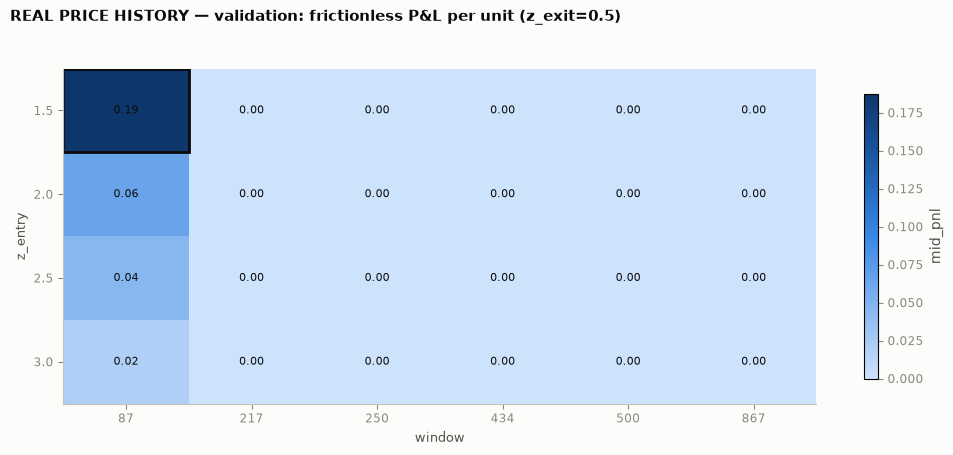

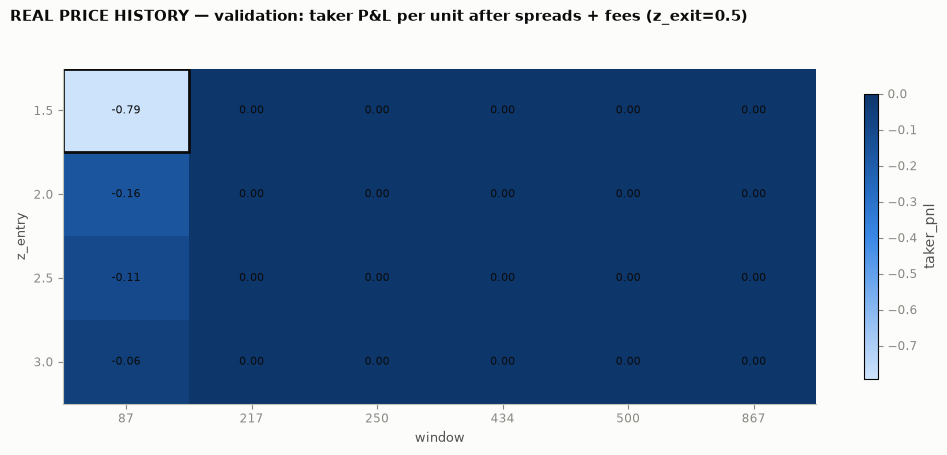

,window,z_entry,z_exit,trades,mid_pnl,mid_hit,taker_pnl
2,87,1.5000,0.5000,13,0.1875,1.0000,-0.7917
0,87,1.5000,0.0000,9,0.1595,1.0000,-0.5184
1,87,1.5000,0.2000,10,0.1585,1.0000,-0.5948
3,87,2.0000,0.0000,3,0.0650,1.0000,-0.1610
4,87,2.0000,0.2000,3,0.0650,1.0000,-0.1610
5,87,2.0000,0.5000,3,0.0650,1.0000,-0.1610
6,87,2.5000,0.0000,2,0.0450,1.0000,-0.1057
7,87,2.5000,0.2000,2,0.0450,1.0000,-0.1057
8,87,2.5000,0.5000,2,0.0450,1.0000,-0.1057
9,87,3.0000,0.0000,1,0.0200,1.0000,-0.0553


In [8]:
grid_kw = dict(windows=windows, z_entries=[1.5, 2.0, 2.5, 3.0], z_exits=[0.0, 0.2, 0.5])
g_mid = fast_grid(sums.iloc[va], F, b_f.n_legs, cost_mode="mid", **grid_kw)
g_tak = fast_grid(sums.iloc[va], F, b_f.n_legs, cost_mode="taker", **grid_kw)
grid = g_mid.rename(columns={"pnl_per_unit": "mid_pnl", "n_trades": "trades", "hit_rate": "mid_hit"})[["window", "z_entry", "z_exit", "trades", "mid_pnl", "mid_hit"]]
grid["taker_pnl"] = g_tak["pnl_per_unit"].to_numpy()
sel = st.plateau_select(grid.assign(score=grid["mid_pnl"]), "score", ["window", "z_entry", "z_exit"])
chosen = sel["params"]
display(Markdown(f"**{sel['n_configs']} configurations tried.** Selected (plateau centre of the frictionless score): "
                 f"N = **{chosen['window']}**, z_entry = **{chosen['z_entry']}**, z_exit = **{chosen['z_exit']}**; "
                 f"best taker score in the whole grid = **{grid['taker_pnl'].max():+.4f}** per basket unit."))
P.show(P.plot_grid_heatmap(grid[grid.z_exit == chosen["z_exit"]], x="window", y="z_entry", value="mid_pnl", data_kind=DK,
                           title=f"validation: frictionless P&L per unit (z_exit={chosen['z_exit']})", selected=chosen), "02_grid_mid")
P.show(P.plot_grid_heatmap(grid[grid.z_exit == chosen["z_exit"]], x="window", y="z_entry", value="taker_pnl", data_kind=DK,
                           title=f"validation: taker P&L per unit after spreads + fees (z_exit={chosen['z_exit']})", selected=chosen), "02_grid_taker")
display(grid.sort_values("mid_pnl", ascending=False).head(10))

In [9]:
best_mid = grid.loc[grid["mid_pnl"].idxmax()]
n_pos = int((grid["taker_pnl"] > 0).sum())
lines = [
    f"* **The sum-to-one structure is in the data.** Johansen finds rank {jo['rank_trace']} with the cointegrating vector {jo['angle_to_iota_deg']:.1f}° from ι, "
    f"and the identity regression gives β = {ir['beta']:.3f}.",
    f"* **Cross-event identities hold only approximately.** House: mean residual {pair_tab.iloc[0]['mean residual']*100:+.2f}c (HAC t {pair_tab.iloc[0]['HAC t']:.1f}), "
    f"half-life {pair_tab.iloc[0]['half-life (h)']:.0f} h; Senate: {pair_tab.iloc[1]['mean residual']*100:+.2f}c (t {pair_tab.iloc[1]['HAC t']:.1f}). "
    "A persistent offset of about a cent is within the two events' combined spreads and their definitional differences (Other / placeholders), so it is not free money.",
    f"* **Signal vs tradability.** On validation the best frictionless configuration earns {best_mid['mid_pnl']:+.3f} per unit over {int(best_mid['trades'])} trades "
    f"(hit rate {best_mid['mid_hit']:.0%}), yet only {n_pos} of {len(grid)} configurations are positive after the {spread:.3f} spread and fees: "
    "the z-signal identifies reversion correctly, but the reversion is smaller than the cost of crossing every leg's spread twice.",
]
display(Markdown("### Conclusions (generated)\n" + "\n".join(lines)))

### Conclusions (generated)
* **The sum-to-one structure is in the data.** Johansen finds rank 1 with the cointegrating vector 5.8° from ι, and the identity regression gives β = -1.039.
* **Cross-event identities hold only approximately.** House: mean residual +0.98c (HAC t 4.9), half-life 14 h; Senate: -0.24c (t -1.6). A persistent offset of about a cent is within the two events' combined spreads and their definitional differences (Other / placeholders), so it is not free money.
* **Signal vs tradability.** On validation the best frictionless configuration earns +0.187 per unit over 13 trades (hit rate 100%), yet only 0 of 72 configurations are positive after the 0.023 spread and fees: the z-signal identifies reversion correctly, but the reversion is smaller than the cost of crossing every leg's spread twice.

In [10]:
selected = {"basket": "fed-oct-2026", "window": int(chosen["window"]), "z_entry": float(chosen["z_entry"]), "z_exit": float(chosen["z_exit"]),
            "selection": "plateau centre of the frictionless validation score", "n_configs": int(sel["n_configs"]),
            "h_train_min": float(h_train), "push_rate_per_min": float(push_rate), "spread_sum": spread, "fee_per_unit": float(F),
            "train": [str(sums.index[tr][0]), str(sums.index[tr][-1])], "validation": [str(sums.index[va][0]), str(sums.index[va][-1])],
            "test": [str(sums.index[te][0]), str(sums.index[te][-1])], "test_start_ns": int(sums.index[te][0].value)}
(RESULTS_ROOT / "selected_params.json").write_text(json.dumps(selected, indent=1))
grid.to_csv(RESULTS_ROOT / "window_grid_validation.csv", index=False)
R.save_dataset_info("02", [info_fed, info_bop, info_house, info_senate], {"selected": selected,
                     "johansen_angle_deg": float(jo["angle_to_iota_deg"]), "pairings": pair_tab.reset_index().to_dict("records")})
selected

{'basket': 'fed-oct-2026',
 'window': 87,
 'z_entry': 1.5,
 'z_exit': 0.5,
 'selection': 'plateau centre of the frictionless validation score',
 'n_configs': 72,
 'h_train_min': 172.83365631545513,
 'push_rate_per_min': 0.05016786940917686,
 'spread_sum': 0.02299999999999991,
 'fee_per_unit': 0.02616312536703994,
 'train': ['2026-09-02 03:01:00+00:00', '2026-09-20 03:03:00+00:00'],
 'validation': ['2026-09-20 09:04:00+00:00', '2026-09-26 03:01:00+00:00'],
 'test': ['2026-09-26 09:02:00+00:00', '2026-10-02 02:59:00+00:00'],
 'test_start_ns': 1790413320000000000}

### Limitations
* Engle–Granger p-values on series that are near the [0, 1] boundaries (House-D ≈ 0.9) are fragile; the identity residual is analysed directly instead.
* Spurious-regression caveats (Granger–Newbold) apply to any cross-event regression without a payoff identity; none is presented as a finding here.
* The window grid is scored on top-of-book sums with a constant spread; notebook 03 re-runs the selected configuration through the full
  depth-walking, latency-aware simulator on the untouched test split.